In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

Dimensiones del dataset: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


,Métrica,Valor
0,Accuracy,0.7390
1,Balanced accuracy,0.7124
2,Macro F1,0.7008
3,Weighted F1,0.7518


,precision,recall,f1-score,support
Dropout,0.8428,0.6796,0.7524,284.000
Enrolled,0.4239,0.6478,0.5124,159.000
Graduate,0.8668,0.8100,0.8374,442.000
accuracy,0.7390,0.7390,0.7390,0.739
macro avg,0.7112,0.7124,0.7008,885.000
weighted avg,0.7795,0.7390,0.7518,885.000


,Predicho: Dropout,Predicho: Enrolled,Predicho: Graduate
Real: Dropout,193,67,24
Real: Enrolled,25,103,31
Real: Graduate,11,73,358


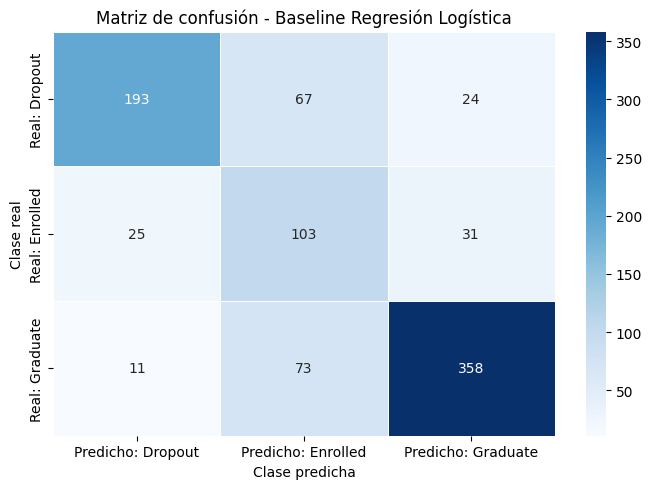

In [2]:
# Cargar datos

df = pd.read_csv("../data/dataset.csv")

# Limpieza por si aparece un carácter raro en el primer nombre de columna
df.columns = df.columns.str.replace("\ufeff", "", regex=False)

print("Dimensiones del dataset:", df.shape)
display(df.head())

# 2. Separar variables

X = df.drop(columns=["Target"])
y = df["Target"]

class_names = sorted(y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Modelo baseline

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

# 4. Tabla resumen de métricas

metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred, average="weighted")
    ]
})

metrics_df["Valor"] = metrics_df["Valor"].round(4)

display(metrics_df)

# 5. Classification report como tabla

report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
report_df = report_df.round(4)

display(report_df)

# 6. Matriz de confusión como tabla

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {c}" for c in class_names],
    columns=[f"Predicho: {c}" for c in class_names]
)

display(cm_df)

# 7. Matriz de confusión como plot

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Matriz de confusión - Baseline Regresión Logística")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

,Métrica,Valor
0,Accuracy,0.7593
1,Balanced accuracy,0.6872
2,Macro F1,0.6939
3,Weighted F1,0.7547


,precision,recall,f1-score,support
Dropout,0.8240,0.7254,0.7715,284.0000
Enrolled,0.4828,0.4403,0.4605,159.0000
Graduate,0.8082,0.8959,0.8498,442.0000
accuracy,0.7593,0.7593,0.7593,0.7593
macro avg,0.7050,0.6872,0.6939,885.0000
weighted avg,0.7548,0.7593,0.7547,885.0000


,Predicho: Dropout,Predicho: Enrolled,Predicho: Graduate
Real: Dropout,206,40,38
Real: Enrolled,33,70,56
Real: Graduate,11,35,396


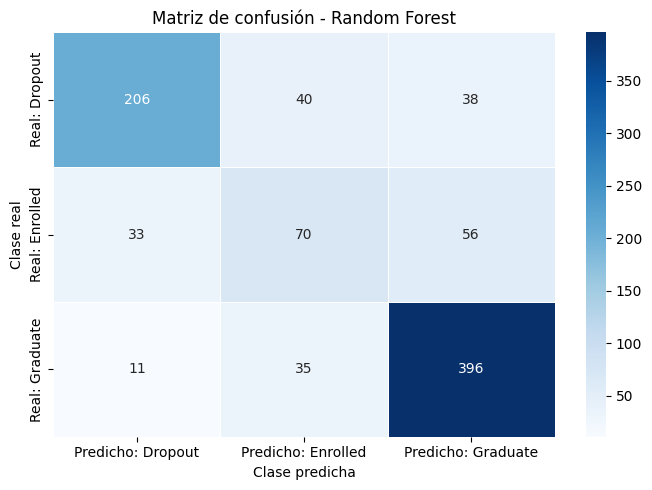

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

rf_metrics_df["Valor"] = rf_metrics_df["Valor"].round(4)

display(rf_metrics_df)

rf_report_df = pd.DataFrame(
    classification_report(y_test, y_pred_rf, output_dict=True)
).T.round(4)

display(rf_report_df)

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_names)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=[f"Real: {c}" for c in class_names],
    columns=[f"Predicho: {c}" for c in class_names]
)

display(cm_rf_df)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()